**ARIMA = Autoregressive Integrated Moving Average**

p = number of previous values used

d = number of times data are differenced

q = number of previous prediction errors used

Simple concept:

Past values + past errors → ARIMA → future values

For this project, we will forecast SPEI-01.

**Find the NetCDF files**

In [45]:
from pathlib import Path

input_folder = Path("/kaggle/input")

nc_files = list(input_folder.rglob("*.nc"))

print("NetCDF files found:", len(nc_files))

for file in nc_files:
    print(file)

NetCDF files found: 2
/kaggle/input/datasets/brsdincer/global-drought-monitor-climate-change-time-range/Drought Monitor/spei48.nc
/kaggle/input/datasets/brsdincer/global-drought-monitor-climate-change-time-range/Drought Monitor/spei01 (1).nc


**Meaning:**

Path() → points to a folder

rglob("*.nc") → finds all .nc files

list() → stores them

for → prints each file

**Expected result:** you should see spei01 (1).nc and spei48.nc.

**Open the SPEI-01 dataset**

Theory: xarray is useful for NetCDF climate data. We will open only the spei01 file.

In [46]:
import xarray as xr

# Select the SPEI-01 file
spei01_file = [f for f in nc_files if "spei01" in f.name.lower()][0]

# Open the dataset
ds = xr.open_dataset(spei01_file)

print(ds)

<xarray.Dataset> Size: 223MB
Dimensions:  (time: 859, lat: 180, lon: 360)
Coordinates:
  * time     (time) datetime64[ns] 7kB 1950-01-01 1950-02-01 ... 2021-07-01
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Data variables:
    spei     (time, lat, lon) float32 223MB ...


**What this does:**

**xarray** → reads NetCDF climate data

**"spei01"** → selects the 1-month SPEI file

**open_dataset()** → opens the dataset

**Extract SPEI for Islamabad**

Theory: ARIMA needs one time series. So we select one location from the global grid.

In [47]:
# Islamabad coordinates
target_lat = 33.7
target_lon = 73.1

# Select nearest grid cell
spei_islamabad = ds["spei"].sel(
    lat=target_lat,
    lon=target_lon,
    method="nearest"
)

print(spei_islamabad)
print("Selected latitude:", float(spei_islamabad.lat.values))
print("Selected longitude:", float(spei_islamabad.lon.values))

<xarray.DataArray 'spei' (time: 859)> Size: 3kB
[859 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 7kB 1950-01-01 1950-02-01 ... 2021-07-01
    lon      float64 8B 73.5
    lat      float64 8B 33.5
Attributes:
    units:      standardized values
    long_name:  standardized precipitation-evapotranspiration index
Selected latitude: 33.5
Selected longitude: 73.5


**What this does:**

**.sel() →** selects a location

**method="nearest"** → uses the nearest available grid point

**Convert to a simple table**

Theory: ARIMA works with a time series, so we convert the selected SPEI data into a pandas DataFrame.

In [48]:
spei_df = spei_islamabad.to_dataframe(name="SPEI").reset_index()

print(spei_df.head(10))

        time   lon   lat      SPEI
0 1950-01-01  73.5  33.5  1.667125
1 1950-02-01  73.5  33.5 -0.265332
2 1950-03-01  73.5  33.5  0.657069
3 1950-04-01  73.5  33.5  0.198708
4 1950-05-01  73.5  33.5 -0.303540
5 1950-06-01  73.5  33.5 -0.558317
6 1950-07-01  73.5  33.5  0.235037
7 1950-08-01  73.5  33.5  1.702498
8 1950-09-01  73.5  33.5  1.085148
9 1950-10-01  73.5  33.5  0.262188


**What this does:**

**to_dataframe() →** converts xarray data to a table

**name="SPEI" →** names the values column

**reset_index() →** makes time a normal column

**Check missing values and basic information**

Theory: Before ARIMA, we must make sure the time series is complete and understand its size and period.

In [49]:
print(spei_df.isnull().sum())

print("\nFirst date:", spei_df["time"].min())
print("Last date:", spei_df["time"].max())
print("Number of observations:", len(spei_df))

print("\nSPEI statistics:")
print(spei_df["SPEI"].describe())

time    0
lon     0
lat     0
SPEI    0
dtype: int64

First date: 1950-01-01 00:00:00
Last date: 2021-07-01 00:00:00
Number of observations: 859

SPEI statistics:
count    859.000000
mean       0.018672
std        0.995450
min       -2.650142
25%       -0.755237
50%       -0.042497
75%        0.782550
max        2.337310
Name: SPEI, dtype: float64


**What this does:**

**isnull().sum() →** checks missing values

**min() / max() →** shows start and end dates

**len() →** gives number of observations

**describe() →** gives mean, standard deviation, minimum, maximum, etc.

**Plot the SPEI time series**

Theory: Before ARIMA, we visually inspect whether the series has a clear trend or roughly fluctuates around a stable mean.

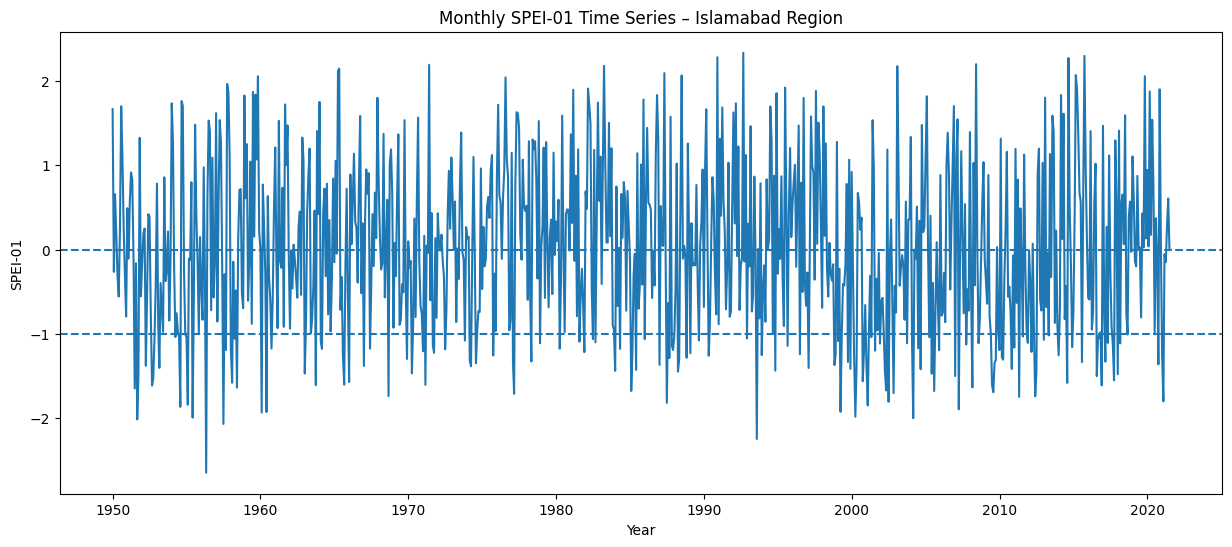

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    spei_df["time"],
    spei_df["SPEI"]
)

plt.axhline(y=0, linestyle="--")
plt.axhline(y=-1, linestyle="--")

plt.title("Monthly SPEI-01 Time Series – Islamabad Region")
plt.xlabel("Year")
plt.ylabel("SPEI-01")

plt.show()

**What to look for:**

Does SPEI fluctuate around 0?

Is there a clear increasing/decreasing trend?

Are there strong dry periods below -1?

**ADF stationarity test**

Theory: ARIMA needs us to determine d.

Stationary series → usually d = 0

Nonstationary series → may need differencing

We use the ADF test.

In [51]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(spei_df["SPEI"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

print("\nCritical Values:")
for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic: -10.220820300870669
p-value: 5.330714194987837e-18

Critical Values:
1% : -3.438039434877692
5% : -2.8649342774762423
10% : -2.5685773775887872


**Plot ACF and PACF**

ACF helps understand possible q

PACF helps understand possible p

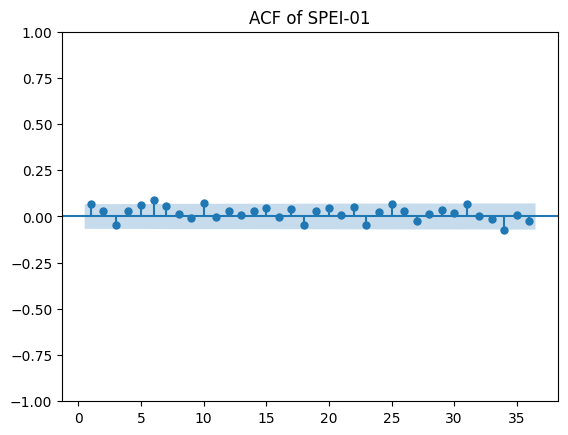

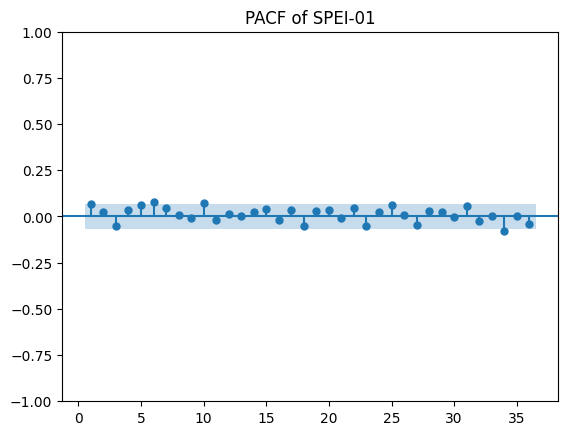

In [52]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(
    spei_df["SPEI"],
    lags=36,
    zero=False
)
plt.title("ACF of SPEI-01")
plt.show()

plot_pacf(
    spei_df["SPEI"],
    lags=36,
    zero=False,
    method="ywm"
)
plt.title("PACF of SPEI-01")
plt.show()

Both ACF and PACF show weak autocorrelation, with no strong clear cutoff.

So:

d = 0 is already known.

p and q are not obvious from these plots.

We should test a few small ARIMA models instead of guessing.

**Prepare train/test data**

For time series, we split chronologically, not randomly.

In [57]:
data = spei_df[["time", "SPEI"]].copy()

data = data.set_index("time")
data = data.asfreq("MS")

split_index = int(len(data) * 0.80)

train = data.iloc[:split_index]
test = data.iloc[split_index:]

print("Training:", len(train))
print("Testing:", len(test))

print("\nTraining period:", train.index.min(), "to", train.index.max())
print("Testing period:", test.index.min(), "to", test.index.max())

Training: 687
Testing: 172

Training period: 1950-01-01 00:00:00 to 2007-03-01 00:00:00
Testing period: 2007-04-01 00:00:00 to 2021-07-01 00:00:00


**Compare candidate ARIMA models**

Since d = 0, we test a few small values of p and q.

Lower AIC and BIC = better model fit with less unnecessary complexity.

In [58]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd

candidate_orders = [
    (0, 0, 0),
    (1, 0, 0),
    (0, 0, 1),
    (1, 0, 1),
    (2, 0, 0),
    (0, 0, 2),
    (2, 0, 1),
    (1, 0, 2)
]

results = []

for order in candidate_orders:
    model = ARIMA(train["SPEI"], order=order)
    fitted_model = model.fit()

    results.append({
        "ARIMA": str(order),
        "AIC": fitted_model.aic,
        "BIC": fitted_model.bic
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("AIC")

print(results_df)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


       ARIMA          AIC          BIC
1  (1, 0, 0)  1926.852950  1940.449953
2  (0, 0, 1)  1927.112880  1940.709883
5  (0, 0, 2)  1928.183351  1946.312688
7  (1, 0, 2)  1928.454535  1951.116206
4  (2, 0, 0)  1928.559923  1946.689261
3  (1, 0, 1)  1928.727610  1946.856947
6  (2, 0, 1)  1928.741364  1951.403036
0  (0, 0, 0)  1929.606402  1938.671071


**What this does:**

fits several ARIMA models

compares their AIC and BIC

sorts them from best to worst by AIC

Lowest AIC: ARIMA(1,0,0) → 1926.85

Lowest BIC: ARIMA(0,0,0) → 1938.67

So AIC prefers ARIMA(1,0,0), while BIC prefers the simpler model.

**Test ARIMA(1,0,0) on unseen data**

AIC/BIC help select candidates, but the real test is forecasting the test period.

We use a rolling one-step forecast:

***Train → predict next month → add actual value → predict next month again.***

In [60]:
history = list(train["SPEI"])
predictions = []

for actual_value in test["SPEI"]:

    model = ARIMA(history, order=(1, 0, 0))
    fitted_model = model.fit()

    forecast = fitted_model.forecast(steps=1)
    predictions.append(forecast[0])

    history.append(actual_value)

**Calculate MAE and RMSE**

We now measure how accurate the ARIMA forecasts are.

MAE = average absolute error

RMSE = gives more penalty to large errors

Lower values = better

In [61]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

actual = test["SPEI"].values

mae = mean_absolute_error(actual, predictions)
rmse = np.sqrt(mean_squared_error(actual, predictions))

print("ARIMA(1,0,0) Results")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))

ARIMA(1,0,0) Results
MAE : 0.8814
RMSE: 1.0452


**Compare with a naïve baseline**

ARIMA should beat a very simple forecast.

**Naïve persistence** means:

Next month SPEI = previous month SPEI

In [62]:
naive_predictions = []

history = list(train["SPEI"])

for actual_value in test["SPEI"]:

    naive_prediction = history[-1]
    naive_predictions.append(naive_prediction)

    history.append(actual_value)

In [63]:
naive_mae = mean_absolute_error(actual, naive_predictions)
naive_rmse = np.sqrt(mean_squared_error(actual, naive_predictions))

print("Naive Forecast Results")
print("MAE :", round(naive_mae, 4))
print("RMSE:", round(naive_rmse, 4))

Naive Forecast Results
MAE : 1.2027
RMSE: 1.4655


ARIMA is clearly better because both errors are lower:

ARIMA MAE: 0.8814 vs Naïve: 1.2027

ARIMA RMSE: 1.0452 vs Naïve: 1.4655

**Plot Actual vs ARIMA vs Naïve**

The graph helps us visually compare how both models follow the actual SPEI values.

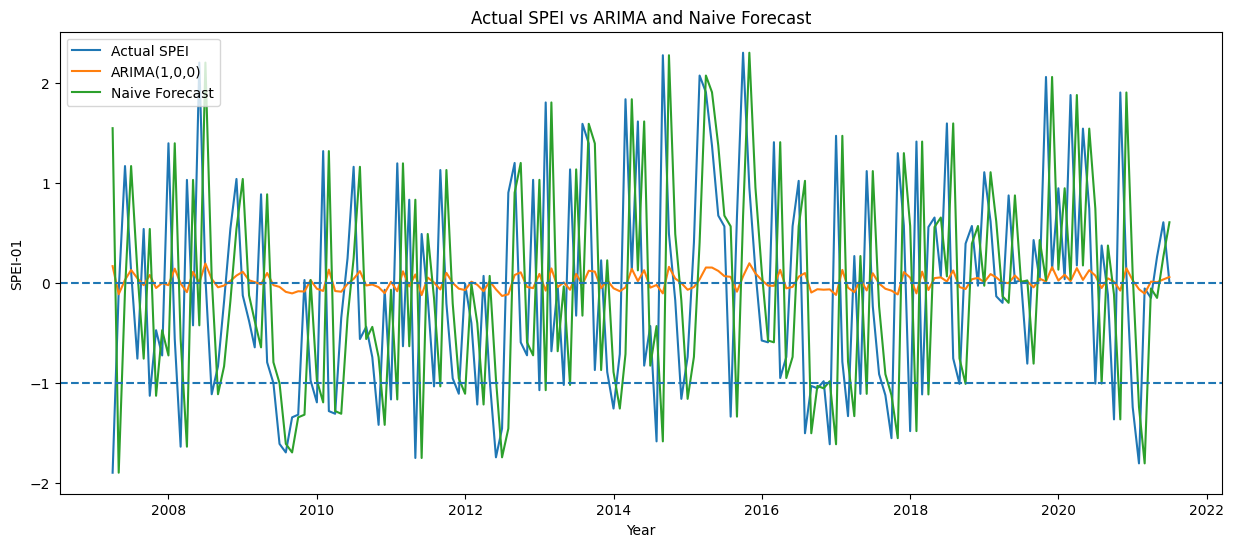

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(test.index, actual, label="Actual SPEI")
plt.plot(test.index, predictions, label="ARIMA(1,0,0)")
plt.plot(test.index, naive_predictions, label="Naive Forecast")

plt.axhline(y=0, linestyle="--")
plt.axhline(y=-1, linestyle="--")

plt.title("Actual SPEI vs ARIMA and Naive Forecast")
plt.xlabel("Year")
plt.ylabel("SPEI-01")

plt.legend()
plt.show()

**What to observe:**

Blue = actual SPEI

Orange = ARIMA forecast

Green = naïve forecast

**Residual diagnostics**

Residual = Actual − Predicted

A good ARIMA model should leave residuals that behave mostly like random noise.

In [65]:
final_train_model = ARIMA(
    train["SPEI"],
    order=(1, 0, 0)
)

final_train_fit = final_train_model.fit()

residuals = final_train_fit.resid

print(residuals.describe())

count    687.000000
mean      -0.000192
std        0.980002
min       -2.658461
25%       -0.747177
50%       -0.056864
75%        0.762774
max        2.308840
dtype: float64


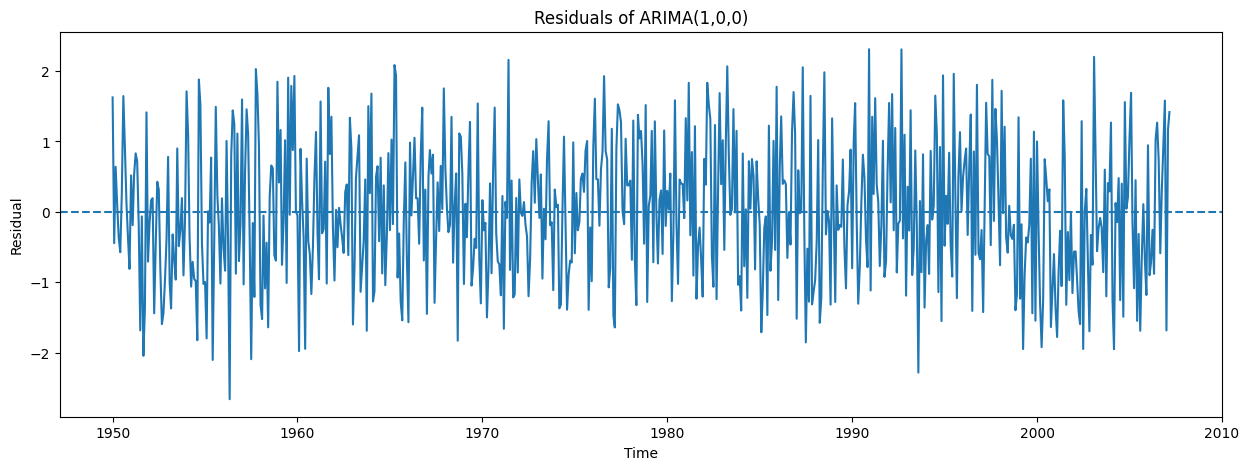

In [66]:
plt.figure(figsize=(15, 5))

plt.plot(residuals)
plt.axhline(y=0, linestyle="--")

plt.title("Residuals of ARIMA(1,0,0)")
plt.xlabel("Time")
plt.ylabel("Residual")

plt.show()

**What to observe:** residuals should fluctuate around 0 without a clear pattern.

**Check residual autocorrelation**

A good ARIMA model should leave residuals with little or no autocorrelation.

First plot residual ACF:

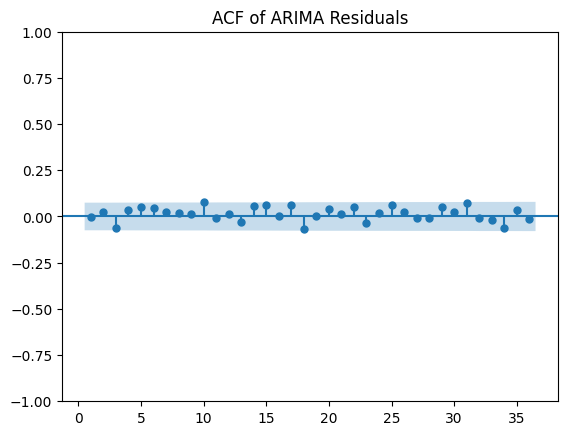

In [71]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    residuals,
    lags=36,
    zero=False
)

plt.title("ACF of ARIMA Residuals")
plt.show()

Ljung-Box test:

In [72]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    residuals,
    lags=[12, 24],
    return_df=True
)

print(ljung_box)

      lb_stat  lb_pvalue
12  12.500241   0.406386
24  28.514526   0.238938


Both p-values are above 0.05:

Lag 12: 0.406

Lag 24: 0.239

So there is no significant residual autocorrelation at these lags.

That means ARIMA(1,0,0) is statistically acceptable for this exercise.

**Fit final model using all data**

Now that the model is selected and checked, fit it on the complete SPEI series before future forecasting.

In [73]:
final_model = ARIMA(
    data["SPEI"],
    order=(1, 0, 0)
)

final_fit = final_model.fit()

print(final_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   SPEI   No. Observations:                  859
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1212.434
Date:                Sun, 16 Aug 2026   AIC                           2430.867
Time:                        10:23:01   BIC                           2445.134
Sample:                    01-01-1950   HQIC                          2436.329
                         - 07-01-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0188      0.037      0.511      0.609      -0.053       0.091
ar.L1          0.0685      0.035      1.936      0.053      -0.001       0.138
sigma2         0.9851      0.061     16.251      0.0

The final model fitted successfully on all 859 observations.

One useful detail from the summary: the AR(1) coefficient is about 0.0685, so the month-to-month dependence is weak, which matches the ACF/PACF plots.

**Forecast the next 12 months**

Now we use the final ARIMA(1,0,0) model to predict future SPEI values.

In [74]:
forecast_result = final_fit.get_forecast(steps=12)

forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

print("12-Month Forecast:")
print(forecast_mean)

print("\n95% Confidence Interval:")
print(forecast_ci)

12-Month Forecast:
2021-08-01    0.017807
2021-09-01    0.018716
2021-10-01    0.018779
2021-11-01    0.018783
2021-12-01    0.018783
2022-01-01    0.018783
2022-02-01    0.018783
2022-03-01    0.018783
2022-04-01    0.018783
2022-05-01    0.018783
2022-06-01    0.018783
2022-07-01    0.018783
Freq: MS, Name: predicted_mean, dtype: float64

95% Confidence Interval:
            lower SPEI  upper SPEI
2021-08-01   -1.927516    1.963129
2021-09-01   -1.931165    1.968597
2021-10-01   -1.931124    1.968681
2021-11-01   -1.931119    1.968685
2021-12-01   -1.931119    1.968685
2022-01-01   -1.931119    1.968685
2022-02-01   -1.931119    1.968685
2022-03-01   -1.931119    1.968685
2022-04-01   -1.931119    1.968685
2022-05-01   -1.931119    1.968685
2022-06-01   -1.931119    1.968685
2022-07-01   -1.931119    1.968685


**Meaning:**

get_forecast(steps=12) → predicts 12 future months

predicted_mean → central forecast

conf_int() → uncertainty range

central forecast is almost constant around:

SPEI ≈ 0.0188

This happens because the AR(1) relationship is weak, so long-range forecasts move toward the series mean.

The 95% confidence interval is wide:

about -1.93 to +1.97

So uncertainty is high.

**Plot the 12-month forecast**

Plot observed SPEI, future forecast, and confidence interval together.

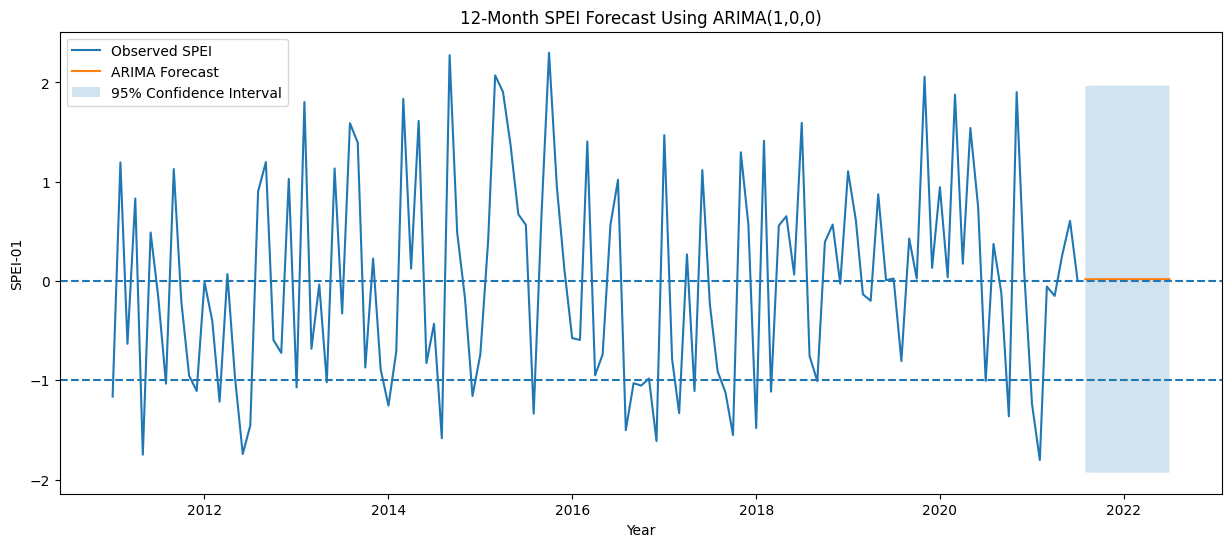

In [75]:
plt.figure(figsize=(15, 6))

recent_data = data.loc["2011":]

plt.plot(
    recent_data.index,
    recent_data["SPEI"],
    label="Observed SPEI"
)

plt.plot(
    forecast_mean.index,
    forecast_mean,
    label="ARIMA Forecast"
)

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.axhline(y=0, linestyle="--")
plt.axhline(y=-1, linestyle="--")

plt.title("12-Month SPEI Forecast Using ARIMA(1,0,0)")
plt.xlabel("Year")
plt.ylabel("SPEI-01")

plt.legend()
plt.show()

**Final interpretation**

  model gives a central forecast near:

  SPEI ≈ 0.02

  So the expected condition is close to normal.

  But the 95% confidence interval is wide, roughly:

  -1.93 to +1.97

  So the model is uncertain about individual future months.

  

**Final conclusion**

For this project:

ADF test → stationary series

d = 0

ACF/PACF → weak dependence

Best practical model → ARIMA(1,0,0)

ARIMA MAE = 0.8814

ARIMA RMSE = 1.0452

ARIMA performed better than the naïve model

Residuals showed no significant autocorrelation

12-month forecast tends toward the mean

The main concept to remember is:

**Check stationarity → choose p,d,q → train → test → compare with baseline → check residuals → forecast future values.**